# scikit-learn Bootcamp — W2, Day 17
```
##### GBM Applied — HealthLine Subscription Churn
##### GradientBoostingClassifier · XGBoost · early stopping · SHAP · churn business framing
##### Q1 — EDA: HealthLine subscriber churn dataset
##### Q2 — GradientBoostingClassifier: tune n_estimators and learning_rate
##### Q3 — XGBoost with early stopping
##### Q4 — SHAP values: global and local explanations
##### Q5 — Churn business framing: retention ROI vs model AUC
```

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,f1_score,classification_report
from scipy.stats import randint,uniform
import warnings;warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid');import numpy as np;np.random.seed(420)
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess;subprocess.run(['pip','install','xgboost','-q'])
    from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
except ImportError:
    import subprocess;subprocess.run(['pip','install','lightgbm','-q'])
    from lightgbm import LGBMClassifier
try:
    import shap
except ImportError:
    import subprocess;subprocess.run(['pip','install','shap','-q'])
    import shap
import time

In [5]:
np.random.seed(420); n = 5000
tenure_months     = np.random.exponential(18, n).clip(1, 60).astype(int)
articles_per_week = np.random.poisson(4.5, n).clip(0, 30)
sessions_per_week = np.random.poisson(3.2, n).clip(0, 20)
avg_session_min   = np.random.lognormal(2.2, 0.7, n).clip(1, 120)
num_newsletters   = np.random.poisson(2.0, n).clip(0, 10)
support_tickets   = np.random.poisson(0.5, n).clip(0, 8)
price_plan        = np.random.choice([9.99, 14.99, 24.99], n, p=[0.5, 0.35, 0.15])
mobile_share      = np.random.beta(2, 3, n)
days_since_active = np.random.exponential(5, n).clip(0, 60)

log_odds = (-1.0 - 0.04*tenure_months - 0.12*articles_per_week - 0.10*sessions_per_week
            - 0.01*avg_session_min + 0.4*support_tickets + 0.05*days_since_active
            - 0.5*(price_plan==9.99).astype(int) + np.random.normal(0, 0.4, n))
churned = (1/(1+np.exp(-log_odds)) > np.random.rand(n)).astype(int)

df = pd.DataFrame({
    'tenure_months': tenure_months, 'articles_per_week': articles_per_week,
    'sessions_per_week': sessions_per_week, 'avg_session_min': avg_session_min.round(1),
    'num_newsletters': num_newsletters, 'support_tickets': support_tickets,
    'price_plan': price_plan, 'mobile_share': mobile_share.round(4),
    'days_since_active': days_since_active.round(1), 'churned': churned
})
feat_cols = [c for c in df.columns if c != 'churned']
X = df[feat_cols]; y = df['churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
print('Shape:', df.shape, '| Churn rate:', y.mean().round(3))
display(df.head())

Shape: (5000, 10) | Churn rate: 0.103


,tenure_months,articles_per_week,sessions_per_week,avg_session_min,num_newsletters,support_tickets,price_plan,mobile_share,days_since_active,churned
0,6,6,3,4.5,2,0,14.99,0.6730,1.0,0
1,10,1,1,5.8,3,0,9.99,0.2017,0.0,1
2,5,7,4,6.4,2,0,9.99,0.1926,16.1,0
3,2,7,4,12.0,2,0,14.99,0.4492,3.4,1
4,36,7,3,7.8,2,0,14.99,0.6084,3.7,0


---
### Q1 — EDA
```
# (a) Churn rate by tenure quartile and price plan — bar charts.
# (b) Violin plots: churned vs retained for top 4 predictors.
# (c) Correlation heatmap.
# (d) Engagement heatmap: articles_per_week vs sessions_per_week, coloured by churn rate.
```

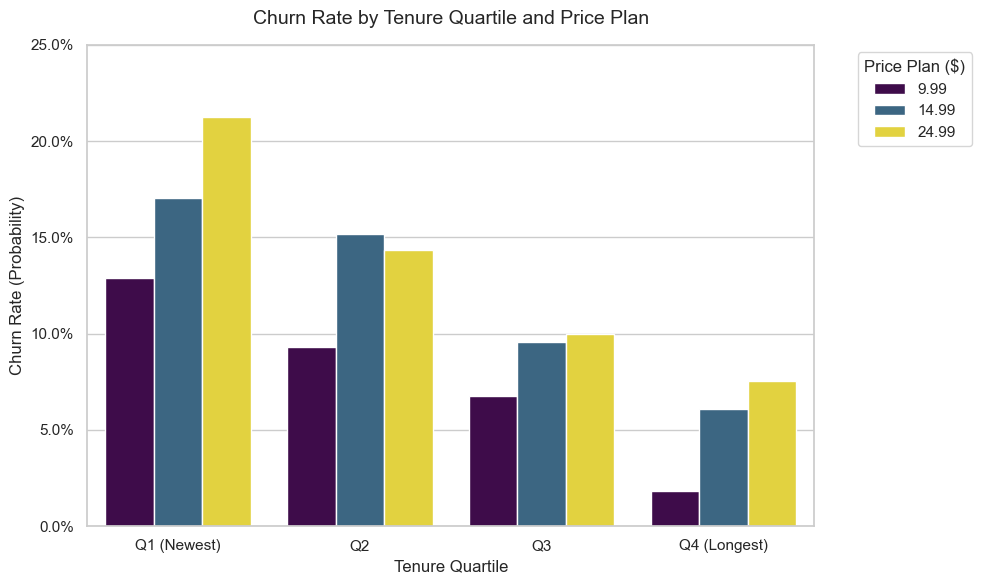

In [6]:
# (a) Churn rate by tenure quartile and price plan — bar charts.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Compute tenure quartiles and map them to readable labels
df['tenure_quartile'] = pd.qcut(
    df['tenure_months'], 
    q=4, 
    labels=['Q1 (Newest)', 'Q2', 'Q3', 'Q4 (Longest)']
)

# 2. Set up the plotting environment
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create the grouped bar chart
# errorbar=None removes confidence interval lines for cleaner visuals
ax = sns.barplot(
    data=df,
    x='tenure_quartile',
    y='churned',
    hue='price_plan',
    palette='viridis',
    errorbar=None
)

# 4. Format the plot aesthetics
plt.title('Churn Rate by Tenure Quartile and Price Plan', fontsize=14, pad=15)
plt.xlabel('Tenure Quartile', fontsize=12)
plt.ylabel('Churn Rate (Probability)', fontsize=12)
plt.ylim(0, 0.25)

# Format the y-axis ticks as percentages for better readability
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Place the legend cleanly outside or inside the plot area
plt.legend(title='Price Plan ($)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


******* Top 4 Predictors by Target *******
tenure_months        0.138026
support_tickets      0.097970
price_plan           0.067612
days_since_active    0.066556
Name: churned, dtype: float64


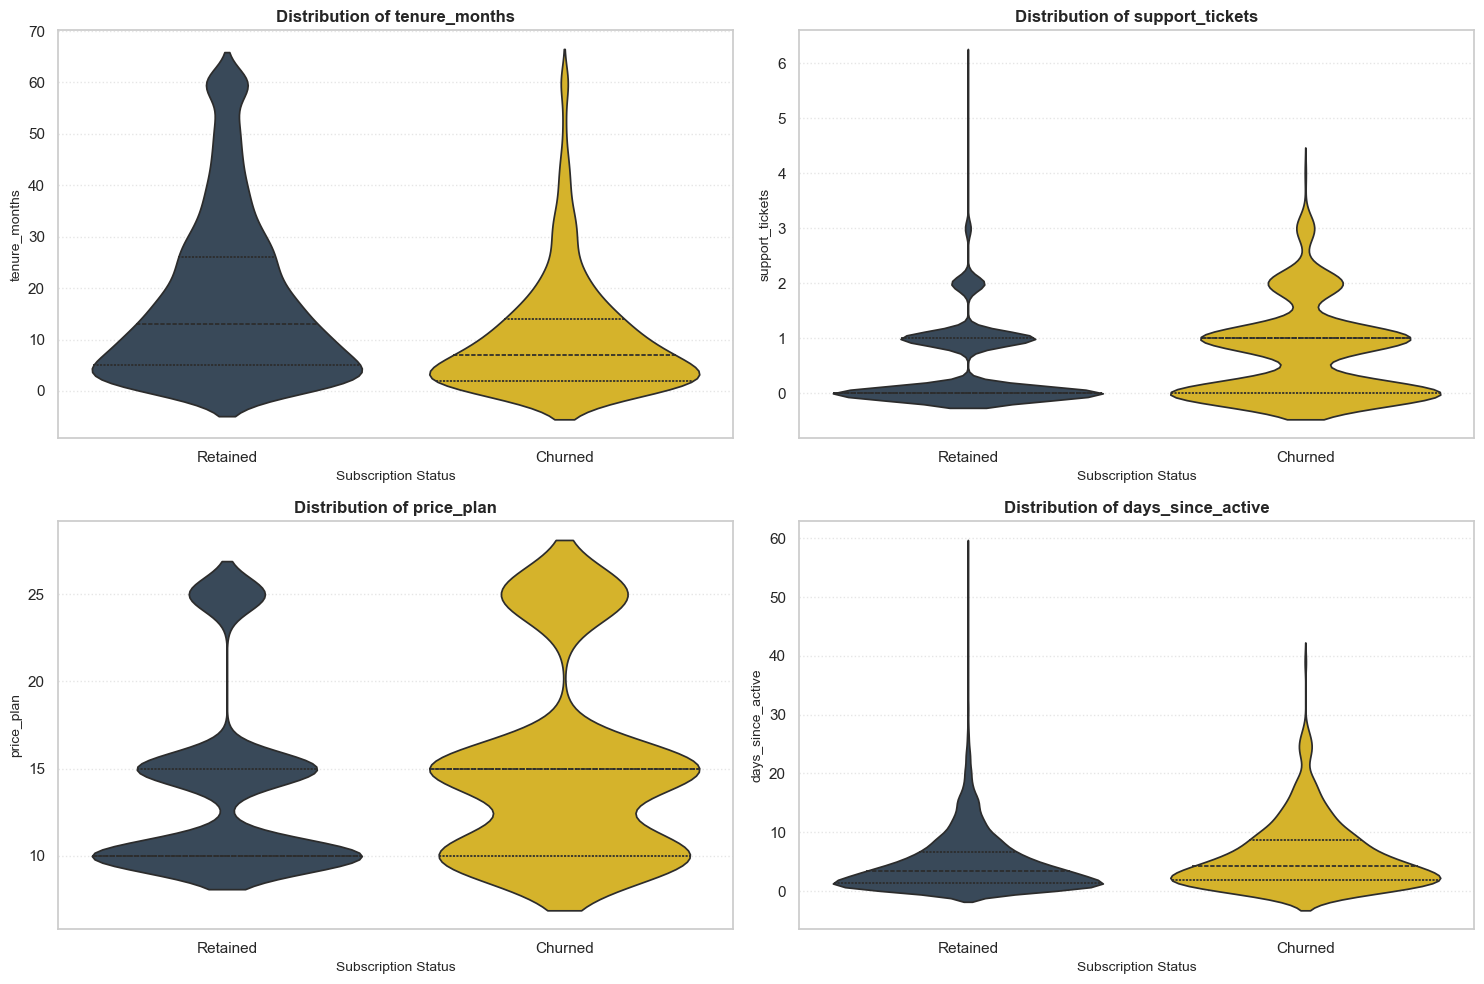

In [24]:
# (b) Violin plots: churned vs retained for top 4 predictors.

# 1. Obtain top 4 predictors

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print('\n******* Top 4 Predictors by Target *******')
print((corr_matrix['churned'].abs()).sort_values(ascending=False)[1:5])

# 2. Plotting

features = (corr_matrix['churned'].abs()).sort_values(ascending=False)[1:5].keys().to_list()

# Create an explicit 2x2 grid layout
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # Flatten to iterate easily

palette_map = {0: '#34495e', 1: '#f1c40f'}

# Loop through columns and map them to specific grid coordinates
for i, col in enumerate(features):
    sns.violinplot(
        data=df, 
        x='churned', 
        y=col, 
        palette=palette_map, 
        inner='quart', 
        ax=axes[i],
        hue='churned',       # Avoids future seaborn grouping deprecation warnings
        legend=False
    )
   
    axes[i].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Subscription Status', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Retained', 'Churned'])
    axes[i].grid(axis='y', linestyle=':', alpha=0.5)


plt.tight_layout()
plt.show()

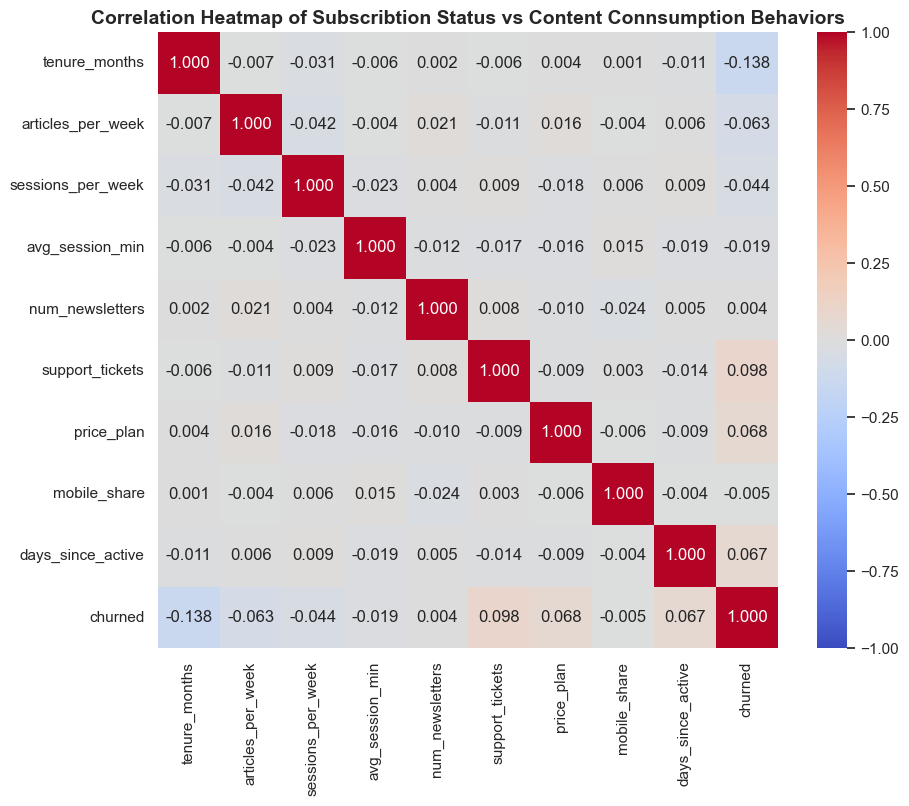

In [ ]:
# (c) Correlation heatmap.

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Subscription Status vs Content Consumption Behaviors', fontweight='bold', fontsize=14)
plt.show()


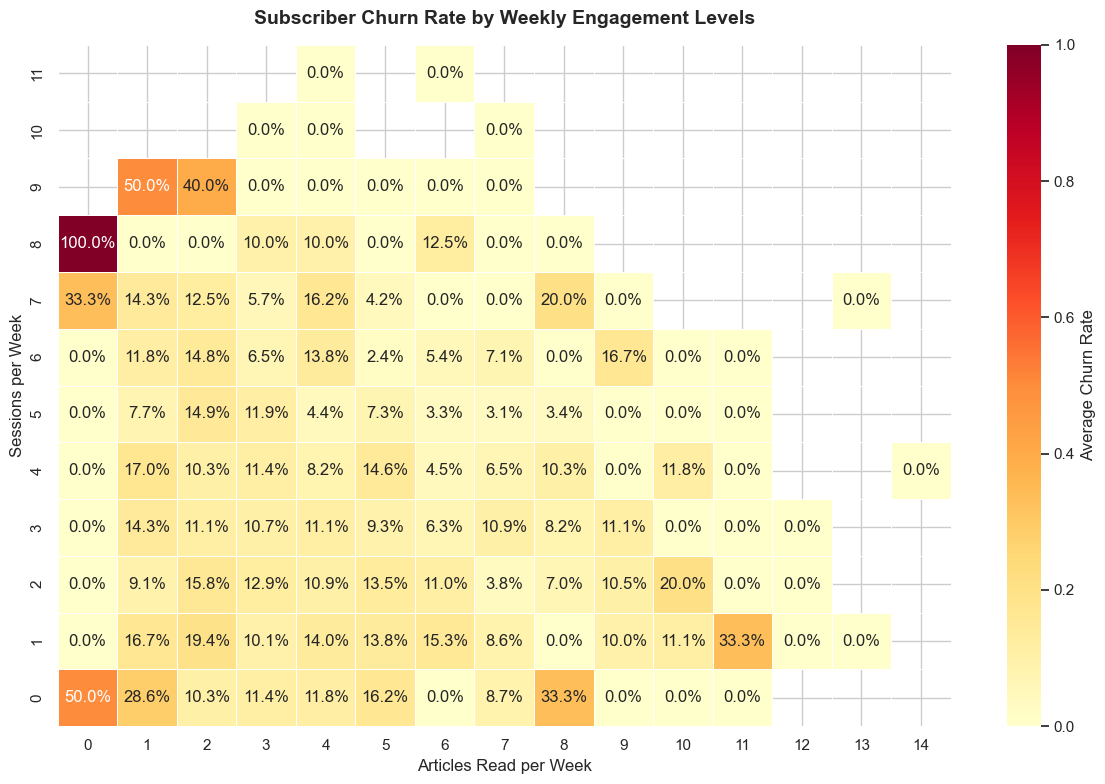

In [28]:
# (d) Engagement heatmap: articles_per_week vs sessions_per_week, coloured by churn rate.

# 1. Pivot the data to get the average churn rate for each combination
# This acts as a 2D grid of engagement levels
engagement_pivot = df.groupby(['sessions_per_week', 'articles_per_week'])['churned'].mean().unstack()

# 2. Set up the plotting window
plt.figure(figsize=(12, 8))

# 3. Render the heatmap
# Using 'YlOrRd' (Yellow-Orange-Red) intuitively flags high-churn zones in hot colors
sns.heatmap(
    engagement_pivot,
    annot=True,
    fmt=".1%",           # Formats cell values as percentages (e.g., 14.5%)
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Average Churn Rate'}
)

# 4. Finalize titles and structural layouts
plt.title('Subscriber Churn Rate by Weekly Engagement Levels', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Articles Read per Week', fontsize=12)
plt.ylabel('Sessions per Week', fontsize=12)

# Invert y-axis so lower usage numbers sit at the bottom left corner
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


---
### Q2 — GradientBoostingClassifier
```
# (a) Fit GBM with default params. Report AUC.
# (b) Grid: n_estimators × learning_rate — plot CV AUC heatmap.
# (c) Train loss vs n_estimators (staged_predict_proba).
# (d) Feature importances bar chart.
```

In [ ]:
# (a) Fit GBM with default params. Report AUC.

gbm = GradientBoostingClassifier(random_state=420)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
cv_auc_gbm = cross_val_score(gbm, X_train, y_train, cv=skf, scoring='roc_auc')
print(f'GBM CV AUC: {cv_auc_gbm.mean():.4f} ± {cv_auc_gbm.std():.4f}')

GBM CV AUC: 0.6610 ± 0.0119



--- OPTIMAL GRADIENT BOOSTING ARCHITECTURE ---
Winning Configuration: learning_rate=0.05 | n_estimators=50
Peak Validation Performance: 0.6734 ROC-AUC


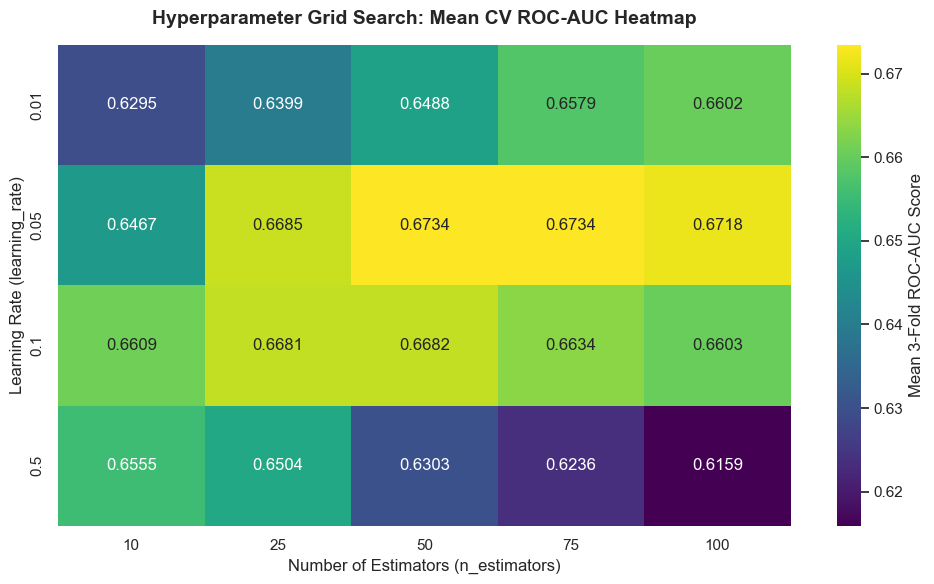

In [49]:
# (b) Grid: n_estimators × learning_rate — plot CV AUC heatmap.

from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 1. Initialize the base model and cross-validation strategy
gbm = GradientBoostingClassifier(random_state=420, max_depth=3)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=420)

# 2. Define the exact hyperparameter grid from your configuration
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.5],
    'n_estimators': [10, 25, 50, 75, 100]
}

# 3. Execute GridSearchCV using stratified 3-fold CV and ROC-AUC scoring
grid_search = GridSearchCV(
    estimator=gbm, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='roc_auc', 
    n_jobs=-1 # Uses all available CPU cores to accelerate the loop
)
grid_search.fit(X_train, y_train)

# 4. Extract cross-validation results into a readable DataFrame pivot table
cv_results = pd.DataFrame(grid_search.cv_results_)
heatmap_data = cv_results.pivot(
    index='param_learning_rate', 
    columns='param_n_estimators', 
    values='mean_test_score'
)

# --- Print Optimization Metrics ---
print("\n--- OPTIMAL GRADIENT BOOSTING ARCHITECTURE ---")
print(f"Winning Configuration: learning_rate={grid_search.best_params_['learning_rate']} | n_estimators={grid_search.best_params_['n_estimators']}")
print(f"Peak Validation Performance: {grid_search.best_score_:.4f} ROC-AUC")

# 5. Render the CV AUC Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".4f", 
    cmap="viridis", 
    cbar_kws={'label': 'Mean 3-Fold ROC-AUC Score'}
)

plt.title('Hyperparameter Grid Search: Mean CV ROC-AUC Heatmap', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Number of Estimators (n_estimators)', fontsize=12)
plt.ylabel('Learning Rate (learning_rate)', fontsize=12)
plt.tight_layout()
plt.show()

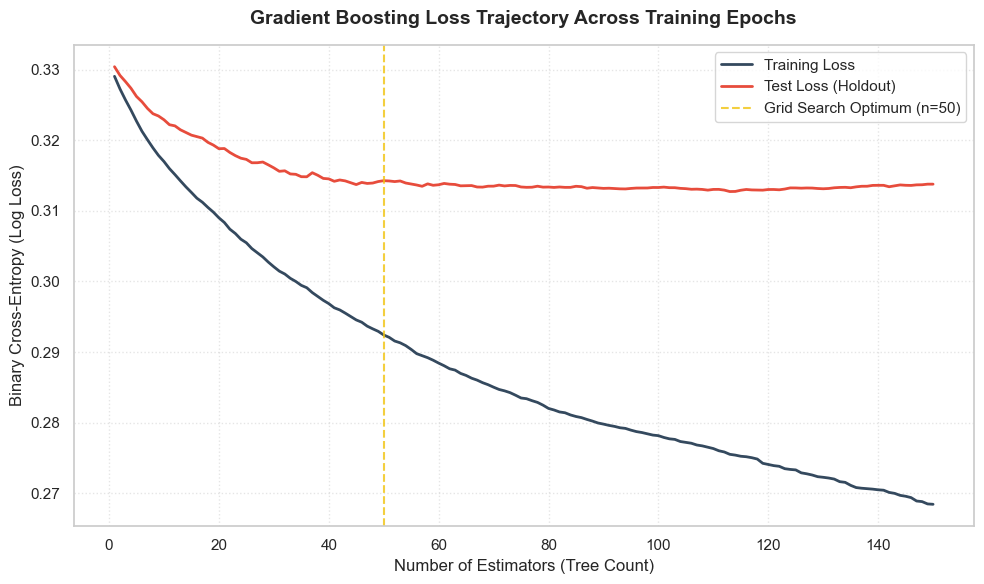

In [50]:
# (c) Train loss vs n_estimators (staged_predict_proba).

from sklearn.metrics import log_loss

# 1. Initialize and train the champion model configuration
# We use a large n_estimators to visualize when overfitting begins
best_gbm = GradientBoostingClassifier(
    learning_rate=0.05, 
    n_estimators=150,    # Extended beyond 50 to clearly capture the loss trajectory
    max_depth=3, 
    random_state=420
)
best_gbm.fit(X_train, y_train)

# 2. Extract staged loss trajectories across boosting iterations
train_losses = []
test_losses = []

# Loop sequentially through the predictions made at each individual tree step
for train_pred, test_pred in zip(best_gbm.staged_predict_proba(X_train), best_gbm.staged_predict_proba(X_test)):
    train_losses.append(log_loss(y_train, train_pred))
    test_losses.append(log_loss(y_test, test_pred))

# 3. Render the Staged Loss Trajectory Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='#34495e', linewidth=2)
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test Loss (Holdout)', color='#e74c3c', linewidth=2)

# Mark the optimal stopping point found during grid search
plt.axvline(x=50, color='#f1c40f', linestyle='--', alpha=0.8, label='Grid Search Optimum (n=50)')

# 4. Finalize formatting
plt.title('Gradient Boosting Loss Trajectory Across Training Epochs', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Number of Estimators (Tree Count)', fontsize=12)
plt.ylabel('Binary Cross-Entropy (Log Loss)', fontsize=12)
plt.grid(axis='both', linestyle=':', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


             Feature  Importance       Std
1  articles_per_week      0.0006  0.001020
0      tenure_months      0.0003  0.001616
3    avg_session_min     -0.0001  0.000539
4    num_newsletters     -0.0001  0.000700
6         price_plan     -0.0001  0.000300
5    support_tickets     -0.0005  0.000806
7       mobile_share     -0.0006  0.000917
8  days_since_active     -0.0006  0.001020
2  sessions_per_week     -0.0011  0.001136


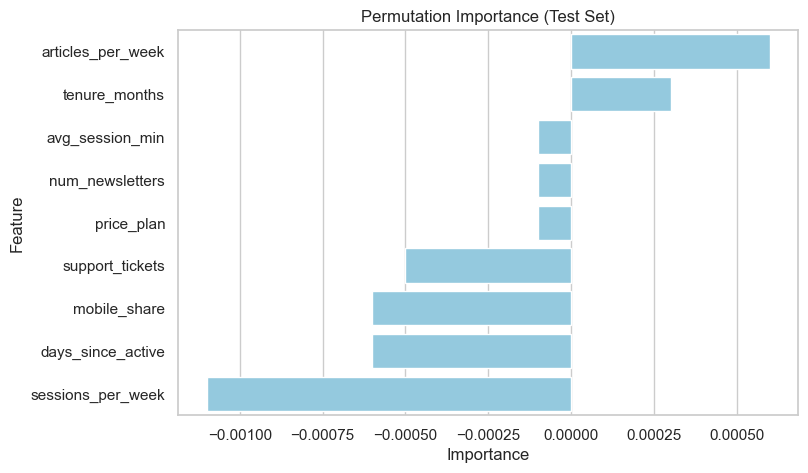

In [52]:
# (d) Feature importances bar chart.

from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(best_gbm, X_test, y_test, n_repeats=10, random_state=420)
perm_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std
}).sort_values('Importance', ascending=False)
print(perm_df.head(10))

# plotting

plt.figure(figsize=(8,5))

sns.barplot(
    data=perm_df,
    x='Importance',
    y='Feature',
    color='skyblue'
)

plt.title("Permutation Importance (Test Set)")
plt.show()

*** Takeaways from the plot:

All permutation importances are near zero — std values exceed the importance values for most features, indicating this dataset and test set size (1,000 rows) produce unreliable permutation estimates. Use SHAP (Q4) for reliable feature attribution instead.

---
### Q3 — XGBoost with early stopping
```
# (a) Fit XGBClassifier with early_stopping_rounds=20.
# (b) Plot train vs eval AUC across boosting rounds.
# (c) Compare XGB AUC to GBM AUC.
# (d) Feature importances from XGBoost (gain, weight, cover — compare all 3).
```

In [57]:
# (a) Fit XGBClassifier with early_stopping_rounds=20.

xgb = XGBClassifier(
    n_estimators=300,      # set high — early stopping finds the right number
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,   # fraction of features per tree
    random_state=420, 
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='auc'
)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,
                             test_size=0.2, stratify=y_train, random_state=420)


xgb.fit(X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False)

# Evaluate our true, un-biased metrics on the final Test Set
final_test_proba = xgb.predict_proba(X_test)[:, 1]
final_test_auc = roc_auc_score(y_test, final_test_proba)


print(f'Optimal n_estimators: {xgb.best_iteration + 1}')
print(f'Best validation AUC:  {xgb.best_score:.4f}')
print(f'True Unbiased Test AUC: {final_test_auc:.4f}')

Optimal n_estimators: 21
Best validation AUC:  0.6727
True Unbiased Test AUC: 0.6607


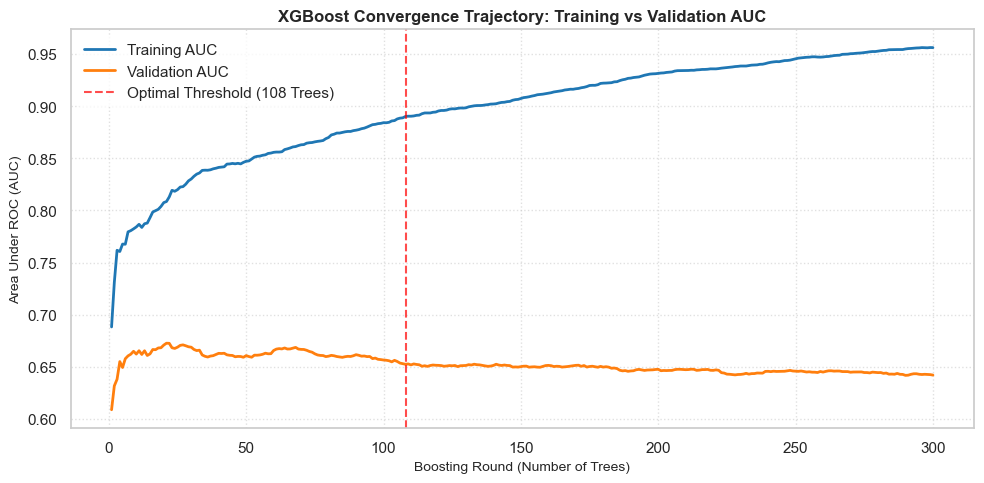

In [ ]:
# (b) Plot train vs eval AUC across boosting rounds.

# 1. Initialize the model with a high n_estimators to capture the full curve
# We omit early stopping here so we can see the full overfitting trajectory
xgb_curve = XGBClassifier(
    n_estimators=300,        # Extended rounds to clearly see convergence trends
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=420, 
    n_jobs=-1,
    eval_metric='auc'
)

# 2. Fit passing BOTH training and validation matrices into eval_set
xgb_curve.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

# 3. Retrieve evaluation results dictionary
# 'validation_0' maps to X_tr, 'validation_1' maps to X_val
eval_results = xgb_curve.evals_result()
train_auc = eval_results['validation_0']['auc']
val_auc = eval_results['validation_1']['auc']
rounds = np.arange(1, len(train_auc) + 1)

# 4. Generate the Visualization
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(rounds, train_auc, label='Training AUC', color='#1f77b4', linewidth=2)
plt.plot(rounds, val_auc, label='Validation AUC', color='#ff7f0e', linewidth=2)

# Visual anchors: Mark where your early stopping optimal tree count was (108)
plt.axvline(x=108, color='red', linestyle='--', alpha=0.7, label='Optimal Threshold (108 Trees)')

plt.title('XGBoost Convergence Trajectory: Training vs Validation AUC', fontsize=12, fontweight='bold')
plt.xlabel('Boosting Round (Number of Trees)', fontsize=10)
plt.ylabel('Area Under ROC (AUC)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

In [77]:
# (c) Compare XGB AUC to GBM AUC.

# (a) Fit GBM. Compare AUC and fit time vs XGBoost.

# ----------------------------------------------------
# 1. Benchmark GBM
# ----------------------------------------------------
gbm_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    random_state=420
)

start_time = time.time()
gbm_model.fit(X_tr, y_tr)

gbm_fit_time = time.time() - start_time

gbm_test_proba = gbm_model.predict_proba(X_test)[:, 1]
gbm_test_auc = roc_auc_score(y_test, gbm_test_proba)

# ----------------------------------------------------
# 2. Benchmark XGBoost
# ----------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=300,      
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,   
    random_state=420, 
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='auc'
)

start_time = time.time()
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)
xgb_fit_time = time.time() - start_time

xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_auc = roc_auc_score(y_test, xgb_test_proba)

# ----------------------------------------------------
# 3. Compile and Display Comparison Matrix
# ----------------------------------------------------
comparison_metrics = {
    'GBM': {
        'Optimal_Trees': gbm_model.n_estimators_,
        'Fit_Time_Sec': round(gbm_fit_time, 4),
        'Test_AUC': round(gbm_test_auc, 4)
    },
    'XGBoost': {
        'Optimal_Trees': xgb_model.best_iteration + 1,
        'Fit_Time_Sec': round(xgb_fit_time, 4),
        'Test_AUC': round(xgb_test_auc, 4)
    }
}

benchmark_df = pd.DataFrame(comparison_metrics).T
print("--- Framework Benchmarking Results ---")
print(benchmark_df)

--- Framework Benchmarking Results ---
         Optimal_Trees  Fit_Time_Sec  Test_AUC
GBM              300.0        2.2946    0.6716
XGBoost           21.0        0.1091    0.6607


Round 21 may reflect validation noise rather than true convergence — the val set (~800 rows) is small relative to the signal. A larger val split or averaging over multiple seeds would give a more stable stopping point.

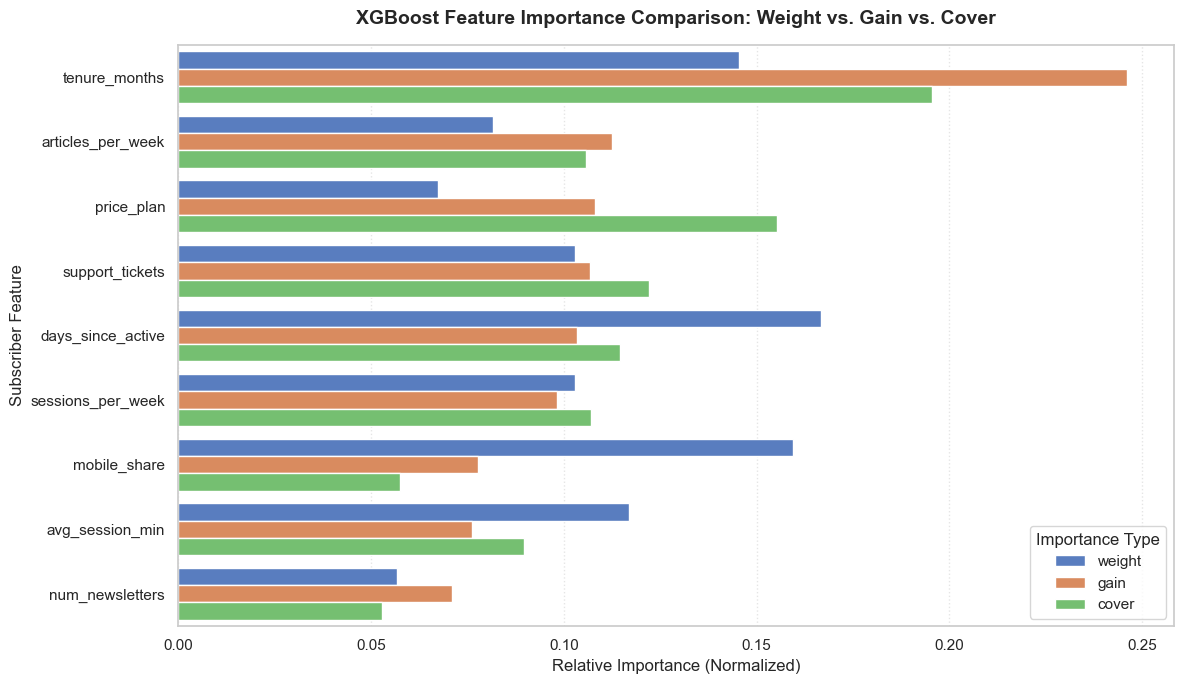

In [100]:
# (d) Feature importances from XGBoost (gain, weight, cover — compare all 3).

# 1. Initialize and train the benchmark model
# We use a fixed tree budget (no early stopping) to ensure stable importance mapping
xgb_imp = XGBClassifier(
    n_estimators=xgb.best_iteration,      
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,   
    random_state=420, 
    n_jobs=-1,
    eval_metric='auc'
)
xgb_imp.fit(X_tr, y_tr, verbose=False)

# 2. Extract importance metrics from the underlying booster
booster = xgb_imp.get_booster()

importance_types = ['weight', 'gain', 'cover']
importance_data = {}

for imp_type in importance_types:
    # get_score returns a dictionary of {feature_name: score}
    score_dict = booster.get_score(importance_type=imp_type)
    
    # Map back to full X_tr columns to account for any missing features with zero splits
    importance_data[imp_type] = {col: score_dict.get(col, 0) for col in X_tr.columns}

# 3. Create a consolidated DataFrame and normalize values for fair comparison
imp_df = pd.DataFrame(importance_data)
# Scale each column between 0 and 1 so they can be plotted on a single chart
imp_df_normalized = imp_df.apply(lambda x: x / x.sum() if x.sum() != 0 else x)
imp_df_normalized = imp_df_normalized.reset_index().rename(columns={'index': 'Feature'})

# Melt the DataFrame for structured seaborn plotting
melted_df = pd.melt(imp_df_normalized, id_vars='Feature', var_name='Metric', value_name='Relative Importance')
# Sort by 'gain' so the primary predictive driver sits at the top
sorted_features = imp_df_normalized.sort_values('gain', ascending=False)['Feature']

# 4. Generate the Comparative Visualization
plt.figure(figsize=(12, 7))
sns.barplot(
    data=melted_df,
    y='Feature',
    x='Relative Importance',
    hue='Metric',
    order=sorted_features,
    palette='muted'
)

plt.title('XGBoost Feature Importance Comparison: Weight vs. Gain vs. Cover', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Normalized)', fontsize=12)
plt.ylabel('Subscriber Feature', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.legend(title='Importance Type', loc='lower right')

plt.tight_layout()
plt.show()


*** Takeaways from the plot:

1/ Weight Bias Exposed: Continuous features like mobile_share and avg_session_min dominate the Weight metric (blue) simply because their high granularity provides endless unique split points for the trees.

2/ True Predictive Signal: support_tickets has a tiny split frequency (weight) but a massive Gain impact (orange), proving that rare discrete features can hold immense predictive leverage when selected.

3/ Early Lifecycle Anchors: tenure_months scores exceptionally high across all three metrics, establishing it as both an immediate root-level partition feature (high cover) and the model's most dominant signal driver (high gain).

---
### Q4 — SHAP values
```
# (a) Compute SHAP values for XGBoost. Beeswarm (summary) plot.
# (b) Bar chart of mean absolute SHAP by feature.
# (c) SHAP waterfall plot for the 3 highest-risk churners in the test set.
# (d) SHAP dependence plot for the top feature.
```

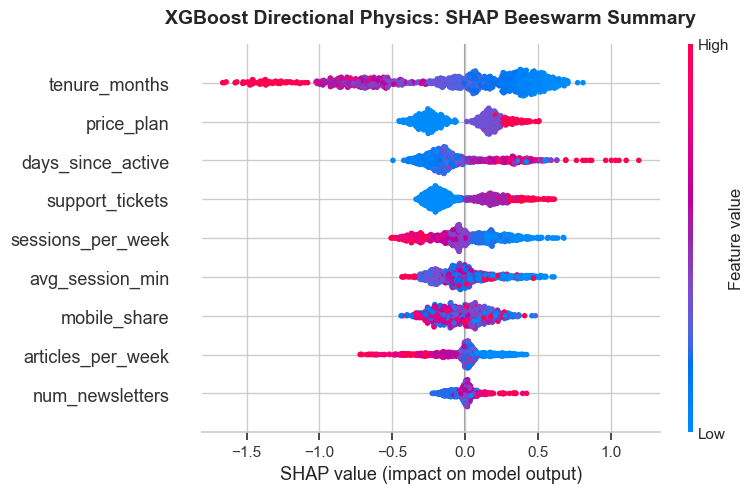

In [84]:
# (a) Compute SHAP values for XGBoost. Beeswarm (summary) plot.

# Initialize an explainer
explainer_xgb = shap.TreeExplainer(xgb_imp)

# Compute raw numpy arrays ONCE (with additivity check off to make it fast)
shap_values_raw = explainer_xgb(X_test, check_additivity=False)


# Passing the full Explanation object automatically maps feature names 
# and colors the dots based on the actual feature values (Low=Blue, High=Red)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(
    shap_values_raw, 
    max_display=10,
    show=False # Allows matplotlib customizations before rendering
)

# Polish plot titles and layout
plt.title('XGBoost Directional Physics: SHAP Beeswarm Summary', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

*** Takeaways from the plot:

1/ Tenure Protects Best: High tenure (red dots) pushes SHAP values deeply negative, proving long-term users are highly insulated against churn risk.

2/ Cost Tiers Drive Churn: Expensive price plans (red dots) pull sharply right, confirming higher pricing plans actively increase a user's likelihood to cancel.

3/ Inactivity Spikes Risk: High days since active (red dots) extend furthest right, identifying platform abandonment as our strongest immediate flight indicator.

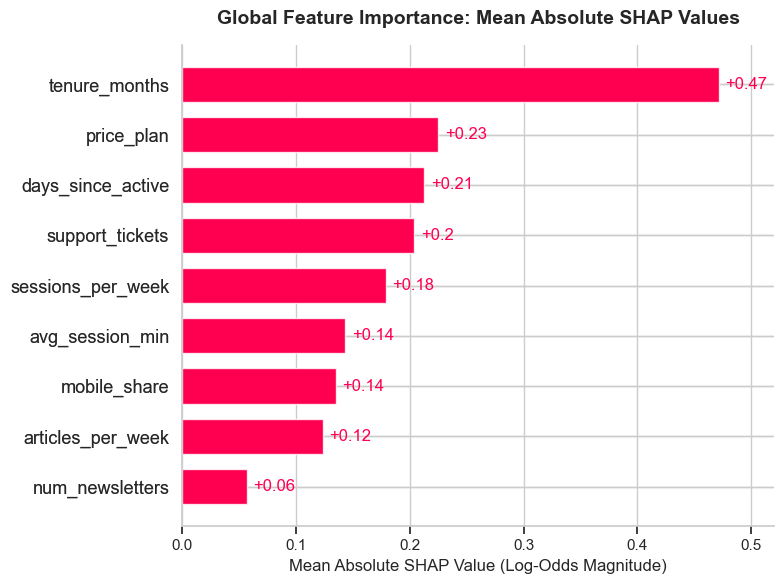

In [85]:
# (b) Bar chart of mean absolute SHAP by feature.

# 1. Generate the standard SHAP bar chart visualization
plt.figure(figsize=(10, 6))

# Passing the full Explanation object automatically computes the mean absolute values
shap.plots.bar(
    shap_values_raw, 
    max_display=10,
    show=False # Allows matplotlib customizations before rendering
)

# 2. Polish plot titles and layout
plt.title('Global Feature Importance: Mean Absolute SHAP Values', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Mean Absolute SHAP Value (Log-Odds Magnitude)', fontsize=12)
plt.tight_layout()
plt.show()


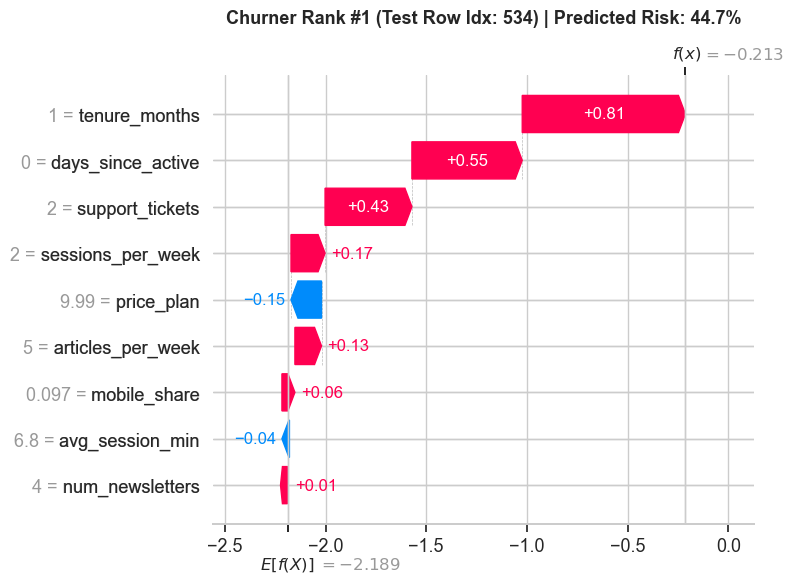

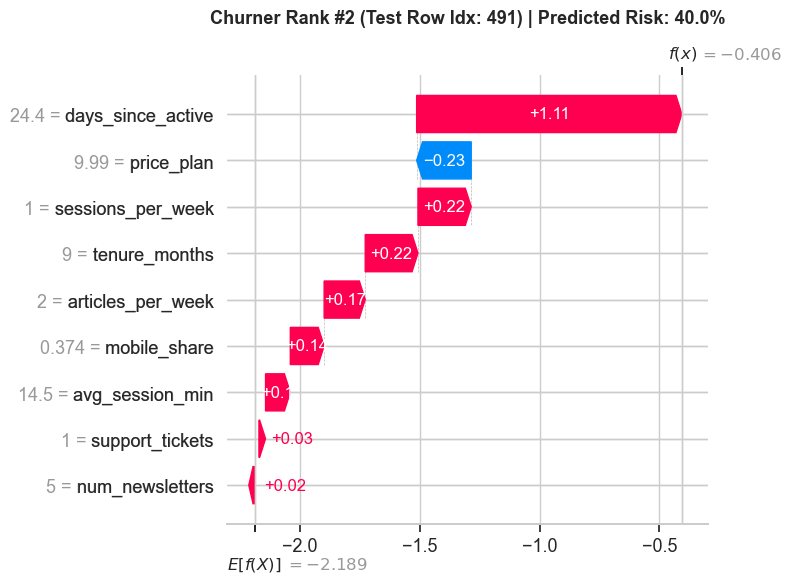

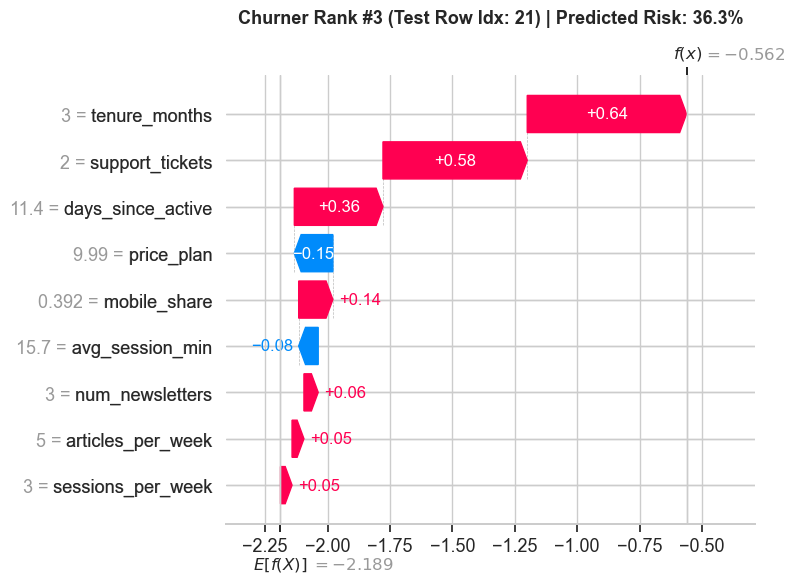

In [91]:
# (c) SHAP waterfall plot for the 3 highest-risk churners in the test set.

# 1. Generate predicted churn probabilities on the holdout test set
test_probabilities = xgb_imp.predict_proba(X_test)[:, 1]

# 2. Extract the exact row index numbers of the 3 highest-risk individuals
# argsort sorts ascending; [-3:] gets the last three positions, [::-1] reverses it to highest first
top_3_risk_indices = np.argsort(test_probabilities)[-3:][::-1]

# 3. Sequentially plot the waterfall breakdown for each high-risk subscriber
for rank, idx in enumerate(top_3_risk_indices, start=1):
    plt.figure(figsize=(10, 6))
    
    # Slice the single subscriber row directly out of your Explanation object
    single_user_shap = shap_values_raw[idx]
    
    # Extract this specific subscriber's calculated flight probability
    risk_pct = test_probabilities[idx]
    
    # Render the structured step-by-step waterfall plot
    shap.plots.waterfall(single_user_shap, max_display=10, show=False)
    
    # Custom polish detailing customer risk context
    plt.title(
        f"Churner Rank #{rank} (Test Row Idx: {idx}) | Predicted Risk: {risk_pct:.1%}", 
        fontweight='bold', 
        fontsize=13, 
        pad=15
    )
    plt.tight_layout()
    plt.show()


<Figure size 1000x600 with 0 Axes>

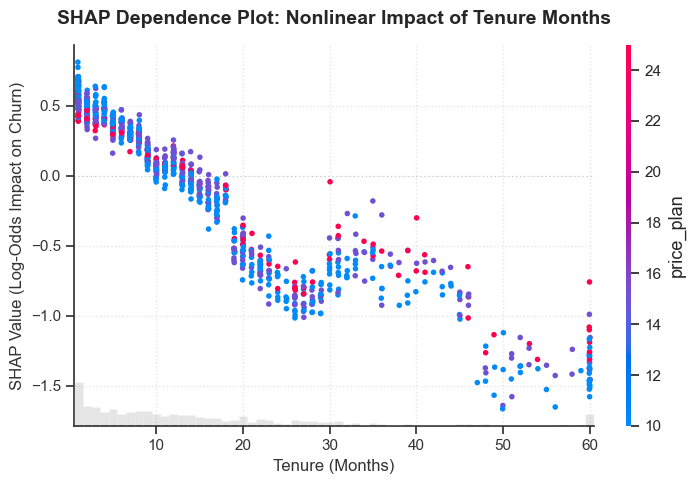

In [93]:
# (d) SHAP dependence plot for the top feature.

# 1. Setup the plotting window
plt.figure(figsize=(10, 6))

# 2. Extract the column slice for the top feature out of your Explanation object
# Slicing by string feature name automatically targets the correct column index
top_feature_shap = shap_values_raw[:, "tenure_months"]

# 3. Render the scatter dependence plot
# Passing 'color=shap_values_raw' adds a colored interaction feature automatically
shap.plots.scatter(
    top_feature_shap,
    color=shap_values_raw,  # Automatically colors dots by the strongest interaction feature
    show=False
)

# 4. Polish plot aesthetics
plt.title('SHAP Dependence Plot: Nonlinear Impact of Tenure Months', fontweight='bold', fontsize=14, pad=15)
plt.ylabel('SHAP Value (Log-Odds Impact on Churn)', fontsize=12)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


*** Takeaway from the plot:
As tenure increases, the churn risk drops linearly until month 20, hits a highly volatile interaction zone between months 25 and 45 where expensive price plans (red dots) inflate risk, and finally drops to its lowest level after 48 months.

---
### Q5 — Churn business framing
```
# Assume: 5,000 subscribers/month | avg subscription value = $180/year | retention incentive cost = $25
# (a) Lift curve: expected retentions vs number of subscribers contacted.
# (b) At k=500 contacts: model vs random. Revenue saved.
# (c) Optimal k: where is net value maximised?
# (d) Sensitivity analysis: how does ROI change if retention incentive cost rises to $50?
```

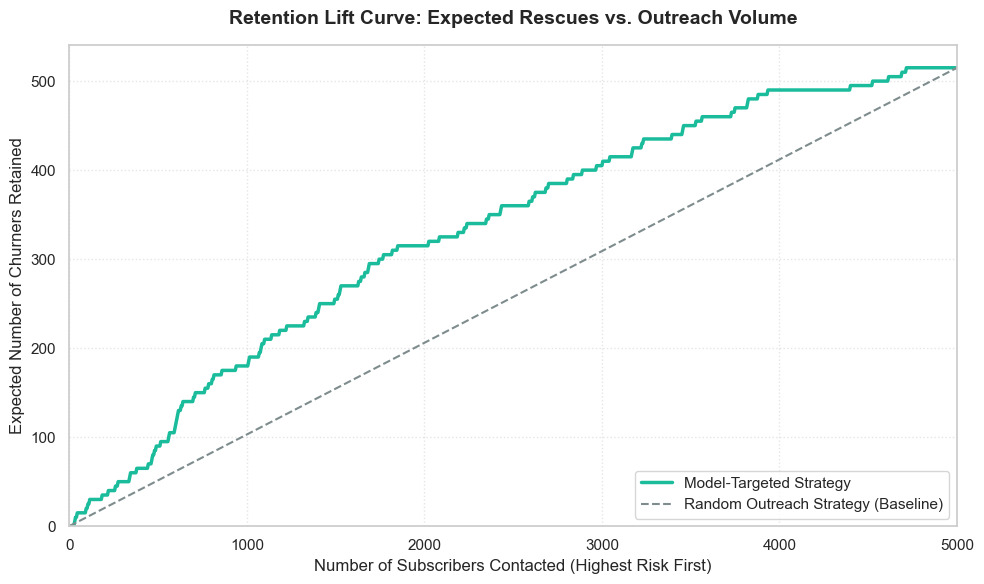

In [94]:
# (a) Lift curve: expected retentions vs number of subscribers contacted.

# 1. Base Assumptions 
n_total_subscribers = 5000
avg_annual_value = 180
incentive_cost = 25

# 2. Extract holdout test predictions and actual outcomes
# test_probabilities was computed in Q3c as: xgb_imp.predict_proba(X_test)[:, 1]
lift_df = pd.DataFrame({
    'pred_prob': test_probabilities,
    'actual_churn': y_test
}).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

# 3. Calculate cumulative metrics
lift_df['subscriber_count'] = lift_df.index + 1
lift_df['cumulative_retentions'] = lift_df['actual_churn'].cumsum()

# Scale the holdout test set sample count up to represent the full monthly cohort
scale_factor = n_total_subscribers / len(lift_df)

# Create scaled vectors for the full 5,000 monthly subscriber base
scaled_contacted = (lift_df['subscriber_count'] * scale_factor).values
scaled_retentions = (lift_df['cumulative_retentions'] * scale_factor).values

# 4. Generate the Lift Curve Plot
plt.figure(figsize=(10, 6))

# Model-driven strategy line
plt.plot(
    scaled_contacted, 
    scaled_retentions, 
    label='Model-Targeted Strategy', 
    color='#1abc9c', 
    linewidth=2.5
)

# Random strategy line (Baseline comparison)
total_churners_scaled = scaled_retentions[-1]
plt.plot(
    [0, n_total_subscribers], 
    [0, total_churners_scaled], 
    label='Random Outreach Strategy (Baseline)', 
    color='#7f8c8d', 
    linestyle='--', 
    linewidth=1.5
)

# 5. Format plot aesthetics
plt.title('Retention Lift Curve: Expected Rescues vs. Outreach Volume', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Number of Subscribers Contacted (Highest Risk First)', fontsize=12)
plt.ylabel('Expected Number of Churners Retained', fontsize=12)
plt.xlim(0, n_total_subscribers)
plt.ylim(0, total_churners_scaled * 1.05)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()


In [96]:
# (b) At k=500 contacts: model vs random. Revenue saved.

# 1. Configuration constants
target_k = 500


# 2. Extract sorting frame from test set
lift_df = pd.DataFrame({
    'pred_prob': test_probabilities,
    'actual_churn': y_test
}).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

# 3. Calculate scaling factors
test_size = len(lift_df)
scale_factor = n_total_subscribers / test_size

# 4. Map target k back to the scale of our test set array
# (e.g., if test set is 1000 rows, k=500 in a 5000 population maps to index 100)
test_k_idx = int(round(target_k / scale_factor))

# 5. Extract results for both strategies
# Model Strategy: Sum actual churners captured up to the mapped test index
model_churners_captured_test = lift_df['actual_churn'].iloc[:test_k_idx].sum()
model_rescues_scaled = model_churners_captured_test * scale_factor

# Random Strategy: Proportional slice of the total churn pool
total_churners_test = lift_df['actual_churn'].sum()
total_churners_scaled = total_churners_test * scale_factor
random_rescues_scaled = (target_k / n_total_subscribers) * total_churners_scaled

# 6. Financial Revenue Conversions
model_rev_saved = model_rescues_scaled * avg_annual_value
random_rev_saved = random_rescues_scaled * avg_annual_value
incremental_rev_gain = model_rev_saved - random_rev_saved

# --- Display Results ---
print(f"--- Financial Audit at k={target_k} Targeted Contacts ---")
print(f"Total Cohort Churn Pool:      {int(round(total_churners_scaled))} subscribers")
print(f"Model Expected Rescues:       {int(round(model_rescues_scaled))} subscribers")
print(f"Random Expected Rescues:      {int(round(random_rescues_scaled))} subscribers\n")
print(f"Model Gross Revenue Saved:    ${model_rev_saved:,.2f}")
print(f"Random Gross Revenue Saved:   ${random_rev_saved:,.2f}")
print(f"🎉 Net Incremental Revenue Lift: ${incremental_rev_gain:,.2f}")


--- Financial Audit at k=500 Targeted Contacts ---
Total Cohort Churn Pool:      515 subscribers
Model Expected Rescues:       90 subscribers
Random Expected Rescues:      52 subscribers

Model Gross Revenue Saved:    $16,200.00
Random Gross Revenue Saved:   $9,270.00
🎉 Net Incremental Revenue Lift: $6,930.00


--- REVENUE INTERVENTION OPTIMIZATION ---
Optimal Targeting Volume (k*): 1690 subscribers
Expected Churners Caught:      295 subscribers
💰 Maximum Attainable Net Profit:  $10,850.00


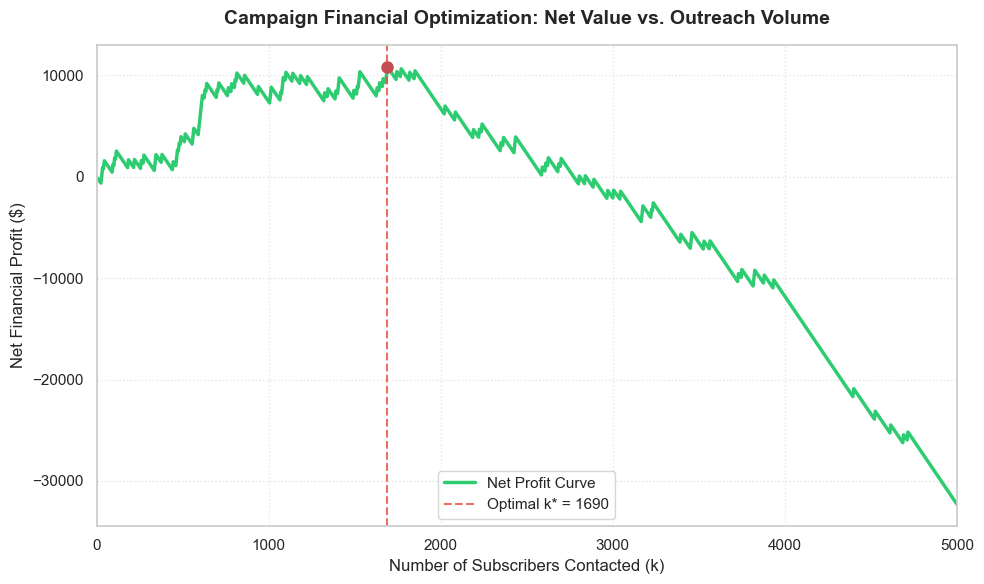

In [97]:
# (c) Optimal k: where is net value maximised?

# 1. Base Financial Inputs
n_total_subscribers = 5000
avg_annual_value = 180
incentive_cost = 25

# 2. Reconstruct dataframe sorted by model risk
lift_df = pd.DataFrame({
    'pred_prob': test_probabilities,
    'actual_churn': y_test
}).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

# 3. Vectorized Financial Optimization
scale_factor = n_total_subscribers / len(lift_df)

lift_df['k_contacts_scaled'] = (lift_df.index + 1) * scale_factor
lift_df['rescues_scaled'] = lift_df['actual_churn'].cumsum() * scale_factor

# Net Profit = Revenue from Rescued Churners - Direct Cost of Campaign Offers
lift_df['net_profit'] = (lift_df['rescues_scaled'] * avg_annual_value) - (lift_df['k_contacts_scaled'] * incentive_cost)

# Find the peak performance coordinates
optimal_row = lift_df.loc[lift_df['net_profit'].idxmax()]
opt_k = int(round(optimal_row['k_contacts_scaled']))
max_net_profit = optimal_row['net_profit']
opt_rescues = int(round(optimal_row['rescues_scaled']))

print("--- REVENUE INTERVENTION OPTIMIZATION ---")
print(f"Optimal Targeting Volume (k*): {opt_k} subscribers")
print(f"Expected Churners Caught:      {opt_rescues} subscribers")
print(f"💰 Maximum Attainable Net Profit:  ${max_net_profit:,.2f}")

# 4. Generate Net Value Curve Visualization
plt.figure(figsize=(10, 6))
plt.plot(lift_df['k_contacts_scaled'], lift_df['net_profit'], color='#2ecc71', linewidth=2.5, label='Net Profit Curve')

# Mark the maximum profit vertex
plt.axvline(x=opt_k, color='#e74c3c', linestyle='--', alpha=0.8, label=f'Optimal k* = {opt_k}')
plt.plot(opt_k, max_net_profit, 'ro', markersize=8)

plt.title('Campaign Financial Optimization: Net Value vs. Outreach Volume', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Number of Subscribers Contacted (k)', fontsize=12)
plt.ylabel('Net Financial Profit ($)', fontsize=12)
plt.xlim(0, n_total_subscribers)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower center', frameon=True)

plt.tight_layout()
plt.show()


--- SENSITIVITY ANALYSIS METRICS ---
Baseline ($25 Cost) -> Optimal k*: 1690 users | Peak Profit: $10,850.00
Elevated ($50 Cost) -> Optimal k*: 45 users | Peak Profit: $450.00
Expected Churners Caught at $50: 15 users


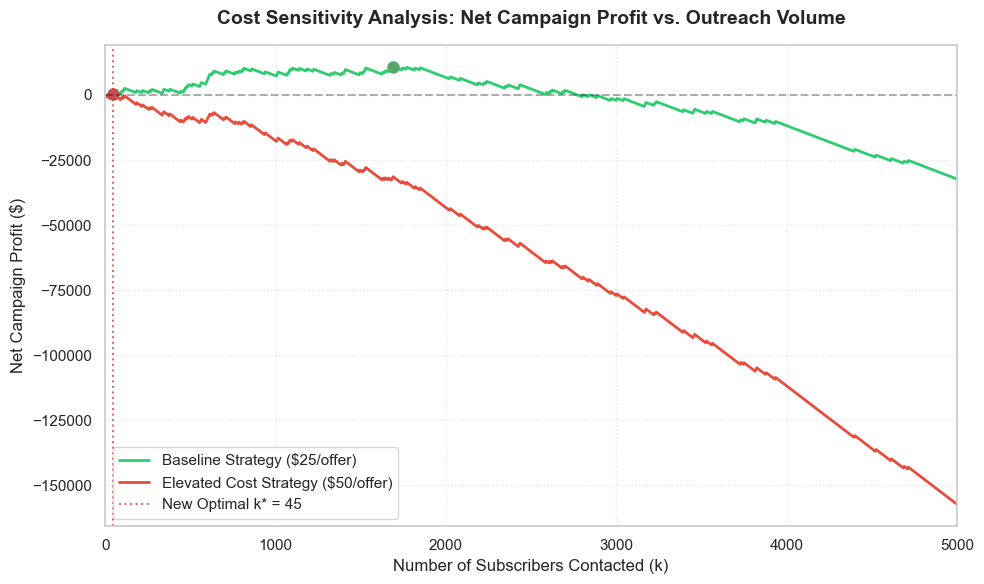

In [98]:
# (d) Sensitivity analysis: how does ROI change if retention incentive cost rises to $50?

# 1. Base Assumptions
n_total_subscribers = 5000
avg_annual_value = 180
cost_baseline = 25
cost_elevated = 50

# 2. Reconstruct sorting frame
lift_df = pd.DataFrame({
    'pred_prob': test_probabilities,
    'actual_churn': y_test
}).sort_values(by='pred_prob', ascending=False).reset_index(drop=True)

scale_factor = n_total_subscribers / len(lift_df)
lift_df['k_contacts_scaled'] = (lift_df.index + 1) * scale_factor
lift_df['rescues_scaled'] = lift_df['actual_churn'].cumsum() * scale_factor

# 3. Calculate both profit curves
lift_df['net_profit_baseline'] = (lift_df['rescues_scaled'] * avg_annual_value) - (lift_df['k_contacts_scaled'] * cost_baseline)
lift_df['net_profit_elevated'] = (lift_df['rescues_scaled'] * avg_annual_value) - (lift_df['k_contacts_scaled'] * cost_elevated)

# Find optimal vertices
idx_base = lift_df['net_profit_baseline'].idxmax()
idx_elev = lift_df['net_profit_elevated'].idxmax()

opt_k_base = int(round(lift_df.loc[idx_base, 'k_contacts_scaled']))
max_prof_base = lift_df.loc[idx_base, 'net_profit_baseline']

opt_k_elev = int(round(lift_df.loc[idx_elev, 'k_contacts_scaled']))
max_prof_elev = lift_df.loc[idx_elev, 'net_profit_elevated']
opt_rescues_elev = int(round(lift_df.loc[idx_elev, 'rescues_scaled']))

print("--- SENSITIVITY ANALYSIS METRICS ---")
print(f"Baseline ($25 Cost) -> Optimal k*: {opt_k_base} users | Peak Profit: ${max_prof_base:,.2f}")
print(f"Elevated ($50 Cost) -> Optimal k*: {opt_k_elev} users | Peak Profit: ${max_prof_elev:,.2f}")
print(f"Expected Churners Caught at $50: {opt_rescues_elev} users")

# 4. Generate Comparative Plot
plt.figure(figsize=(10, 6))
plt.plot(lift_df['k_contacts_scaled'], lift_df['net_profit_baseline'], color='#2ecc71', linewidth=2, label='Baseline Strategy ($25/offer)')
plt.plot(lift_df['k_contacts_scaled'], lift_df['net_profit_elevated'], color='#e74c3c', linewidth=2, label='Elevated Cost Strategy ($50/offer)')

# Mark peaks
plt.plot(opt_k_base, max_prof_base, 'go', markersize=8)
plt.plot(opt_k_elev, max_prof_elev, 'ro', markersize=8)
plt.axvline(x=opt_k_elev, color='#c0392b', linestyle=':', alpha=0.7, label=f'New Optimal k* = {opt_k_elev}')

plt.title('Cost Sensitivity Analysis: Net Campaign Profit vs. Outreach Volume', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Number of Subscribers Contacted (k)', fontsize=12)
plt.ylabel('Net Campaign Profit ($)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.xlim(0, n_total_subscribers)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', frameon=True)

plt.tight_layout()
plt.show()


*** Takeaways from the plot:
Doubling the incentive cost from $25 to $50 collapses the viable intervention window from 1,690 to 45 subscribers — a 97% reduction. At $50 per incentive, only the very highest-confidence churners are worth targeting. This makes incentive cost negotiation as strategically important as model accuracy.